In [2]:
# load data
Italy1 <- read.delim("/Users/zihuahuang/Documents/SSMS/data/level4ec_and_pathway/mgs_level4ec_relab_unstratified/Italy1_mgs_level4ec_relab_unstratified.tsv",row.names = 1)
Italy2 <- read.delim("/Users/zihuahuang/Documents/SSMS/data/level4ec_and_pathway/mgs_level4ec_relab_unstratified/Italy2_mgs_level4ec_relab_unstratified.tsv",row.names = 1)
Austria <- read.delim("/Users/zihuahuang/Documents/SSMS/data/level4ec_and_pathway/mgs_level4ec_relab_unstratified/Austria_mgs_level4ec_relab_unstratified.tsv",row.names = 1)

#
predicted_level4ec_spiec_Austriaasref_Italy1 <- read.delim('/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi/predicted_level4ec_spiec_Austriaasref_Italy1.csv', row.names = 1)
predicted_level4ec_spiec_Austriaasref_Italy1_knn <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_knn/predicted_level4ec_spiec_Austriaasref_Italy1.csv",row.names = 1)
predicted_level4ec_spiec_Austriaasref_Italy1_online <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_online/predicted_level4ec_spiec_Austriaasref_Italy1.csv", row.names = 1)

#
predicted_level4ec_spiec_Italy2asref_Italy1 <- read.delim('/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi/predicted_level4ec_spiec_Italy2asref_Italy1.csv', row.names = 1)
predicted_level4ec_spiec_Italy2asref_Italy1_knn <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_knn/predicted_level4ec_spiec_Italy2asref_Italy1.csv",row.names = 1)
predicted_level4ec_spiec_Italy2asref_Italy1_online <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_online/predicted_level4ec_spiec_Italy2asref_Italy1.csv", row.names =   1)

#
predicted_level4ec_spiec_Italy1asref_Italy2 <- read.delim('/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi/predicted_level4ec_spiec_Italy1asref_Italy2.csv', row.names = 1)
predicted_level4ec_spiec_Italy1asref_Italy2_knn <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_knn/predicted_level4ec_spiec_Italy1asref_Italy2.csv",row.names = 1)
predicted_level4ec_spiec_Italy1asref_Italy2_online <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_online/predicted_level4ec_spiec_Italy1asref_Italy2.csv", row.names = 1)

#
predicted_level4ec_spiec_Austriaasref_Italy2 <- read.delim('/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi/predicted_level4ec_spiec_Austriaasref_Italy2.csv', row.names = 1)
predicted_level4ec_spiec_Austriaasref_Italy2_knn <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_knn/predicted_level4ec_spiec_Austriaasref_Italy2.csv",row.names = 1)
predicted_level4ec_spiec_Austriaasref_Italy2_online <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_online/predicted_level4ec_spiec_Austriaasref_Italy2.csv", row.names = 1)

#
predicted_level4ec_spiec_Italy1asref_Austria <- read.delim('/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi/predicted_level4ec_spiec_Italy1asref_Austria.csv', row.names = 1)
predicted_level4ec_spiec_Italy1asref_Austria_knn <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_knn/predicted_level4ec_spiec_Italy1asref_Austria.csv",row.names = 1)
predicted_level4ec_spiec_Italy1asref_Austria_online <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_online/predicted_level4ec_spiec_Italy1asref_Austria.csv", row.names = 1)

#
predicted_level4ec_spiec_Italy2asref_Austria <- read.delim('/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi/predicted_level4ec_spiec_Italy2asref_Austria.csv', row.names = 1)
predicted_level4ec_spiec_Italy2asref_Austria_knn <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_knn/predicted_level4ec_spiec_Italy2asref_Austria.csv",row.names = 1)
predicted_level4ec_spiec_Italy2asref_Austria_online <- read.delim("/Users/zihuahuang/Documents/SSMS/data/imputed_ec/spieceasi_online/predicted_level4ec_spiec_Italy2asref_Austria.csv", row.names = 1)

In [8]:
# function to binarize the matrices
# binarize, calc_metrics function
binarize <- function(mat) {
  mat_bin <- ifelse(mat > 0, 1, 0)
  return(mat_bin)
}

calc_metrics <- function(pred_bin, truth_bin) {
  TP <- sum(pred_bin == 1 & truth_bin == 1)
  FP <- sum(pred_bin == 1 & truth_bin == 0)
  TN <- sum(pred_bin == 0 & truth_bin == 0)
  FN <- sum(pred_bin == 0 & truth_bin == 1)
  
  Precision <- ifelse((TP+FP)==0, NA, TP/(TP+FP))
  Recall    <- ifelse((TP+FN)==0, NA, TP/(TP+FN))
  F1        <- ifelse(is.na(Precision)|is.na(Recall), NA,
                      2*Precision*Recall/(Precision+Recall))
  
  return(c(TP=TP, FP=FP, TN=TN, FN=FN,
           Precision=Precision, Recall=Recall, F1=F1))
}

# mgs
Italy1_bin <- binarize(Italy1)
Italy2_bin <- binarize(Italy2)
Austria_bin <- binarize(Austria)

# imputed ssms
Austriaasref_Italy1_preds_bin <- list(
  spiec   = binarize(predicted_level4ec_spiec_Austriaasref_Italy1),
  knn     = binarize(predicted_level4ec_spiec_Austriaasref_Italy1_knn),
  online  = binarize(predicted_level4ec_spiec_Austriaasref_Italy1_online)
)

Austriaasref_Italy2_preds_bin <- list(
  spiec   = binarize(predicted_level4ec_spiec_Austriaasref_Italy2),
  knn     = binarize(predicted_level4ec_spiec_Austriaasref_Italy2_knn),
  online  = binarize(predicted_level4ec_spiec_Austriaasref_Italy2_online)
)

Italy2asref_Italy1_preds_bin <- list(
  spiec   = binarize(predicted_level4ec_spiec_Italy2asref_Italy1),
  knn     = binarize(predicted_level4ec_spiec_Italy2asref_Italy1_knn),
  online  = binarize(predicted_level4ec_spiec_Italy2asref_Italy1_online)
)

Italy1asref_Italy2_preds_bin <- list(
  spiec   = binarize(predicted_level4ec_spiec_Italy1asref_Italy2),
  knn     = binarize(predicted_level4ec_spiec_Italy1asref_Italy2_knn),
  online  = binarize(predicted_level4ec_spiec_Italy1asref_Italy2_online)
)

Italy2asref_Austria_preds_bin <- list(
  spiec   = binarize(predicted_level4ec_spiec_Italy2asref_Austria),
  knn     = binarize(predicted_level4ec_spiec_Italy2asref_Austria_knn),
  online  = binarize(predicted_level4ec_spiec_Italy2asref_Austria_online)
)

Italy1asref_Austria_preds_bin <- list(
  spiec   = binarize(predicted_level4ec_spiec_Italy1asref_Austria),
  knn     = binarize(predicted_level4ec_spiec_Italy1asref_Austria_knn),
  online  = binarize(predicted_level4ec_spiec_Italy1asref_Austria_online)
)

# Calculate all methods at once
Austriaasref_Italy1_preds_df <- as.data.frame(do.call(rbind, lapply(Austriaasref_Italy1_preds_bin, calc_metrics, truth_bin=Italy1_bin)))
Austriaasref_Italy1_preds_df$Method <- rownames(Austriaasref_Italy1_preds_df)
rownames(Austriaasref_Italy1_preds_df) <- NULL

Austriaasref_Italy2_preds_df <- as.data.frame(do.call(rbind, lapply(Austriaasref_Italy2_preds_bin, calc_metrics, truth_bin=Italy2_bin)))
Austriaasref_Italy2_preds_df$Method <- rownames(Austriaasref_Italy2_preds_df)
rownames(Austriaasref_Italy2_preds_df) <- NULL  

Italy2asref_Italy1_preds_df <- as.data.frame(do.call(rbind, lapply(Italy2asref_Italy1_preds_bin, calc_metrics, truth_bin=Italy1_bin)))
Italy2asref_Italy1_preds_df$Method <- rownames(Italy2asref_Italy1_preds_df)
rownames(Italy2asref_Italy1_preds_df) <- NULL 

Italy1asref_Italy2_preds_df <- as.data.frame(do.call(rbind, lapply(Italy1asref_Italy2_preds_bin, calc_metrics, truth_bin=Italy2_bin)))
Italy1asref_Italy2_preds_df$Method <- rownames(Italy1asref_Italy2_preds_df)
rownames(Italy1asref_Italy2_preds_df) <- NULL

Italy2asref_Austria_preds_df <- as.data.frame(do.call(rbind, lapply(Italy2asref_Austria_preds_bin, calc_metrics, truth_bin=Austria_bin)))
Italy2asref_Austria_preds_df$Method <- rownames(Italy2asref_Austria_preds_df)
rownames(Italy2asref_Austria_preds_df) <- NULL

Italy1asref_Austria_preds_df <- as.data.frame(do.call(rbind, lapply(Italy1asref_Austria_preds_bin, calc_metrics, truth_bin=Austria_bin)))
Italy1asref_Austria_preds_df$Method <- rownames(Italy1asref_Austria_preds_df)
rownames(Italy1asref_Austria_preds_df) <- NULL






print(Italy2asref_Italy1_preds_df)
print(Austriaasref_Italy1_preds_df)
print(Italy1asref_Italy2_preds_df)
print(Austriaasref_Italy2_preds_df)
print(Italy1asref_Austria_preds_df)
print(Italy2asref_Austria_preds_df)


     TP    FP    TN    FN Precision    Recall        F1 Method
1 95677 69681 21062 22061 0.5786052 0.8126263 0.6759333  spiec
2 95210 69448 21295 22528 0.5782288 0.8086599 0.6743013    knn
3 95210 69448 21295 22528 0.5782288 0.8086599 0.6743013 online
     TP    FP    TN    FN Precision    Recall        F1 Method
1 97386 71344 19399 20352 0.5771706 0.8271416 0.6799084  spiec
2 97242 71234 19509 20496 0.5771861 0.8259186 0.6795055    knn
3 97242 71234 19509 20496 0.5771861 0.8259186 0.6795055 online
     TP    FP    TN    FN Precision    Recall        F1 Method
1 72355 45851 16789 18067 0.6121094 0.8001924 0.6936269  spiec
2 72240 45810 16830 18182 0.6119441 0.7989206 0.6930427    knn
3 72240 45810 16830 18182 0.6119441 0.7989206 0.6930427 online
     TP    FP    TN    FN Precision    Recall        F1 Method
1 72764 45423 17217 17658 0.6156684 0.8047157 0.6976113  spiec
2 72523 45366 17274 17899 0.6151804 0.8020504 0.6962954    knn
3 72523 45366 17274 17899 0.6151804 0.8020504 0.6962954

Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.1 erstellt"


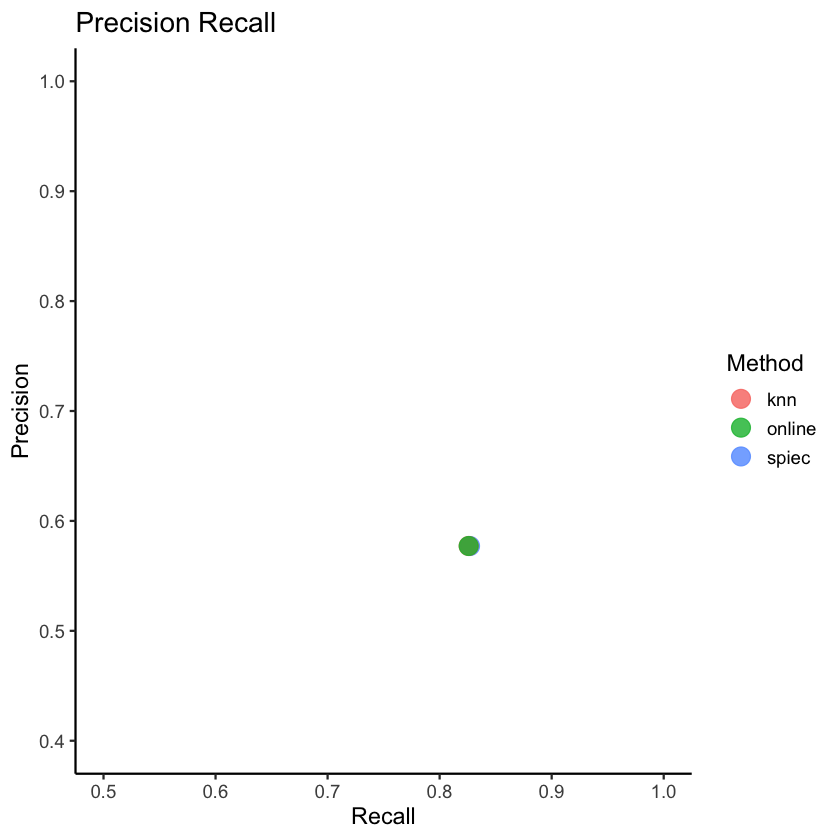

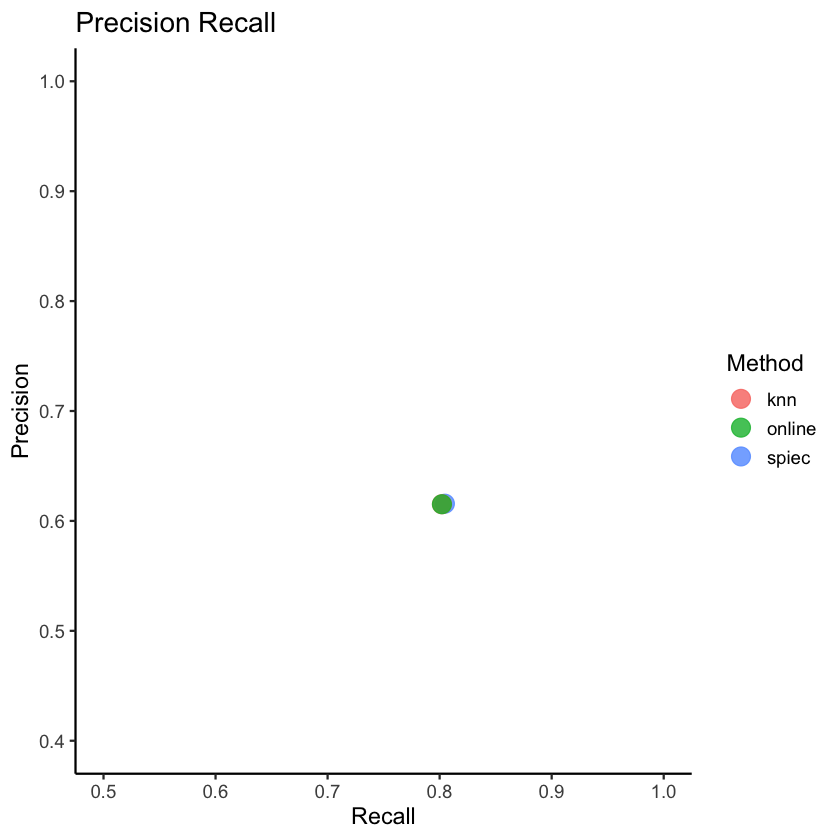

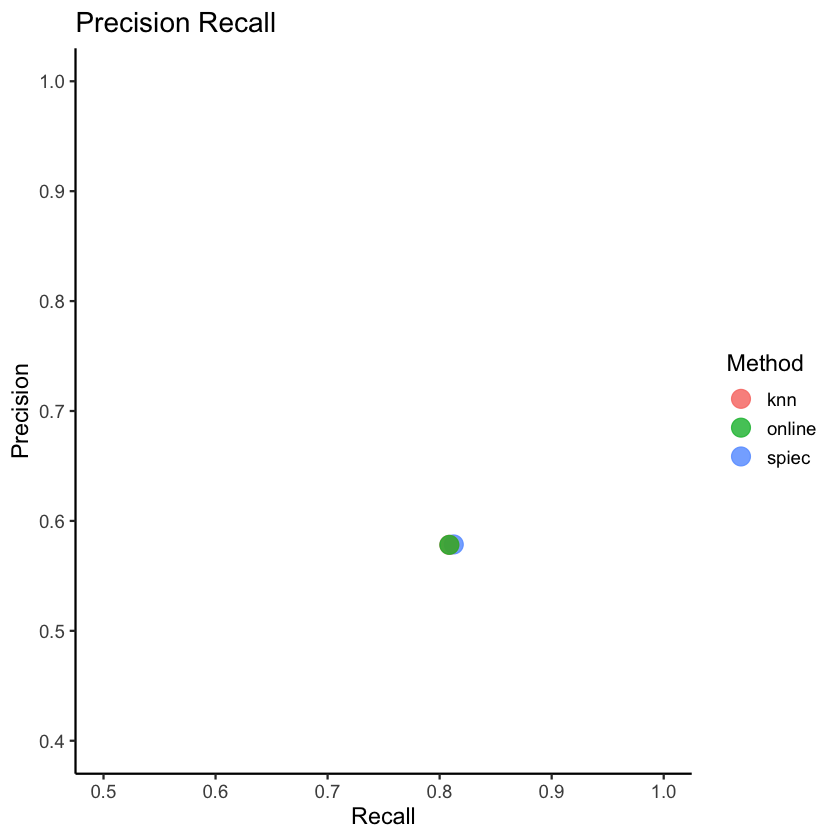

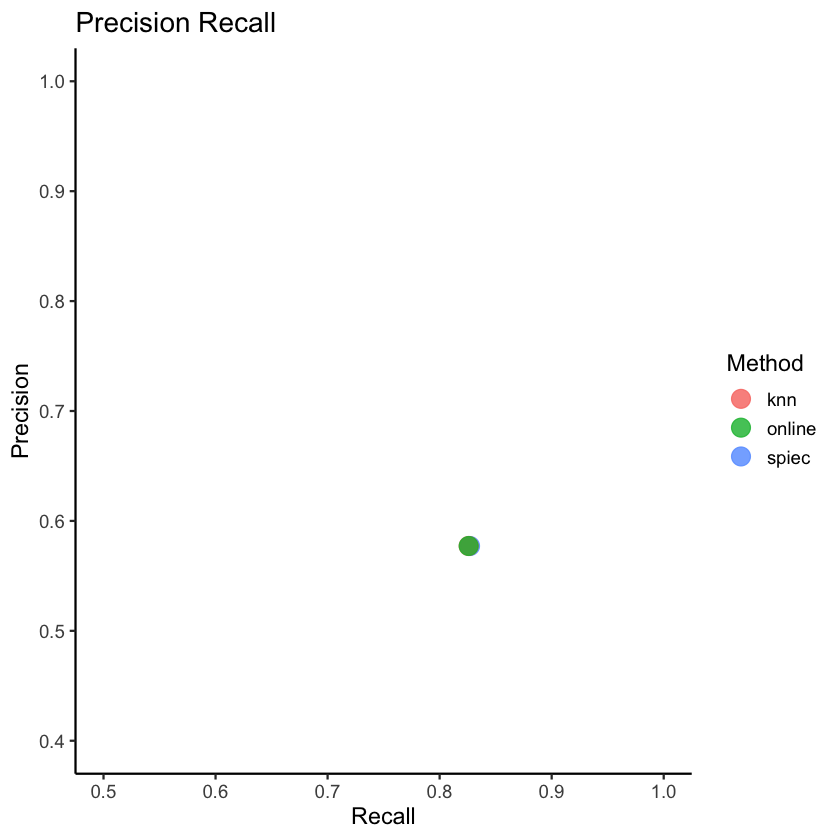

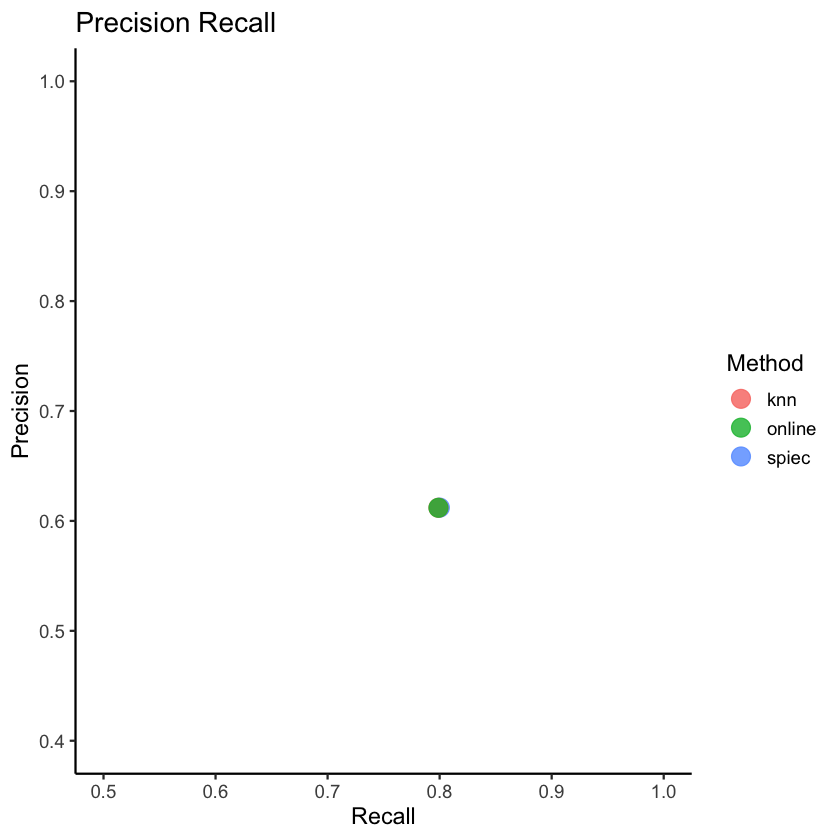

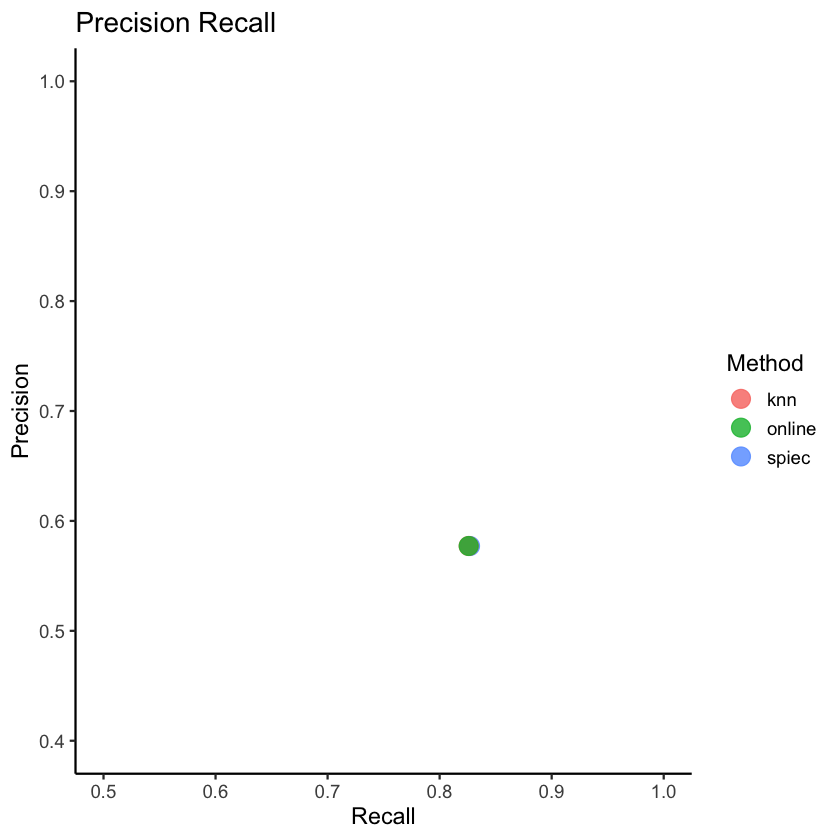

In [5]:
library(ggplot2)

ggplot(Austriaasref_Italy1_preds_df, aes(x = Recall, y = Precision, color = Method)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_x_continuous(limits = c(0.5, 1), breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(limits = c(0.4, 1), breaks = seq(0.4, 1, 0.1)) +
  theme_classic(base_size = 14) +
  labs(title = "Precision Recall",
       x = "Recall", y = "Precision")

ggplot(Austriaasref_Italy2_preds_df, aes(x = Recall, y = Precision, color = Method)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_x_continuous(limits = c(0.5, 1), breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(limits = c(0.4, 1), breaks = seq(0.4, 1, 0.1)) +
  theme_classic(base_size = 14) +
  labs(title = "Precision Recall",
       x = "Recall", y = "Precision")

ggplot(Italy2asref_Italy1_preds_df, aes(x = Recall, y = Precision, color = Method)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_x_continuous(limits = c(0.5, 1), breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(limits = c(0.4, 1), breaks = seq(0.4, 1, 0.1)) +
  theme_classic(base_size = 14) +
  labs(title = "Precision Recall",
       x = "Recall", y = "Precision")

ggplot(Austriaasref_Italy1_preds_df, aes(x = Recall, y = Precision, color = Method)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_x_continuous(limits = c(0.5, 1), breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(limits = c(0.4, 1), breaks = seq(0.4, 1, 0.1)) +
  theme_classic(base_size = 14) +
  labs(title = "Precision Recall",
       x = "Recall", y = "Precision")


ggplot(Italy1asref_Italy2_preds_df, aes(x = Recall, y = Precision, color = Method)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_x_continuous(limits = c(0.5, 1), breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(limits = c(0.4, 1), breaks = seq(0.4, 1, 0.1)) +
  theme_classic(base_size = 14) +
  labs(title = "Precision Recall",
       x = "Recall", y = "Precision")

ggplot(Austriaasref_Italy1_preds_df, aes(x = Recall, y = Precision, color = Method)) +
  geom_point(size = 5, alpha = 0.8) +
  scale_x_continuous(limits = c(0.5, 1), breaks = seq(0.5, 1, 0.1)) +
  scale_y_continuous(limits = c(0.4, 1), breaks = seq(0.4, 1, 0.1)) +
  theme_classic(base_size = 14) +
  labs(title = "Precision Recall",
       x = "Recall", y = "Precision")